# 📘 Notebook 06 — Link Prediction: Predicting Hidden & Future Connections

## 🎯 Learning Objectives

By the end of this notebook, you will understand:
- What link prediction is and why it matters
- How to use graph structure to predict missing/future edges
- Heuristic methods (fast, interpretable)
- Machine learning approaches (powerful, flexible)
- Real-world fraud detection applications

---

## 🔗 What is Link Prediction?

**Link Prediction** answers the fundamental question:

> "Which pairs of nodes are likely to connect in the future (or are already connected but hidden)?"

### Simple Intuition

Imagine a social network:
- Alice knows Bob
- Alice knows Carol
- Bob knows Carol

🤔 **Question:** What's the probability that Alice and Carol will become friends in the future?

**Intuition:** High! Because:
1. They share a common friend (Bob)
2. Social networks naturally create triangles (clustering)
3. Structural properties suggest future connection

### Real-World Examples

| Domain | Problem | Solution |
| --- | --- | --- |
| **Social Networks** | Friend recommendations | Predict who should connect |
| **E-commerce** | Product recommendations | Predict which items user will buy |
| **Protein Networks** | Drug discovery | Predict protein interactions |
| **Fraud Detection** | Find hidden conspiracies | Predict collusion before it manifests |

### 🚨 Why Link Prediction is Critical for Fraud Detection

In fraud networks:
- **Known facts:** Some fraudsters caught, some transactions flagged
- **Hidden reality:** Many connections not yet discovered
- **Link prediction:** Reveals hidden relationships, mule networks, collusion patterns

**Real scenario:**
```
Account A → (known fraud)
Account B → (unknown, but similar)
Account A and B share 5 common accounts they transact with

Link Prediction: HIGH PROBABILITY that A and B are in the same fraud ring!
```

---

## 📚 Theoretical Foundation: Why Link Prediction Works

### Core Principle: Preferential Attachment

Networks don't form randomly. They follow patterns:

1. **Homophily** ("Like attracts like"): Similar nodes connect
2. **Common neighbors:** Shared connections increase link probability
3. **Structural patterns:** Triangles, clustering, and cycles predict future edges
4. **Temporal evolution:** Networks grow in predictable ways

### Key Network Properties That Enable Prediction

| Property | Effect on Link Prediction | Fraud Implication |
| --- | --- | --- |
| **Clustering** | Triangles predict closure | Dense fraud rings have high clustering |
| **Degree distribution** | Hub nodes attract links | High-degree nodes = transaction hubs |
| **Community structure** | Within-community links more likely | Fraud rings = tight communities |
| **Path lengths** | Short paths suggest connection | Fraud networks are highly connected |

---

## 🔗 Types of Link Prediction Methods

Link prediction techniques fall into 3 categories:

### 1️⃣ **Heuristic Methods** (Graph Structure Only)
- Use graph topology directly
- Fast, interpretable, deterministic
- Perfect for beginners and production systems
- Examples: Common Neighbors, Jaccard, Adamic-Adar, Preferential Attachment

### 2️⃣ **Machine Learning Methods** (Features + Models)
- Extract features from graph structure
- Train supervised models (Logistic Regression, Random Forests, etc.)
- More powerful but less interpretable
- Examples: Features from centrality + classification

### 3️⃣ **Graph Embedding Methods** (Deep Learning)
- Convert nodes to dense vectors
- Learn low-dimensional representations
- Highest accuracy, black-box models
- Examples: Node2Vec, GraphSAGE, GCN

---

## 🎯 HEURISTIC METHODS: Simple & Powerful

The core idea: **Use graph structure to score node pairs**

### 📍 Method 1: Common Neighbors

**Definition:**
Count how many neighbors two nodes share.

**Intuition:**
> "The more friends you share, the more likely you are to become friends"

**Formula:**
```
CN(A, B) = |Neighbors(A) ∩ Neighbors(B)|
```

**Example:**
```
Graph:    A --- B --- C
          |     |
          +---- D

Common neighbors of A and B: {C, D}
Score = 2
```

**Why it works:**
- Shared neighbors provide "bridges" for new connections
- Common social circles increase chance of connection
- Simple but effective baseline

**Limitations:**
- Biased toward densely connected regions
- High-degree nodes naturally have more common neighbors
- May miss connections between peripheral nodes

**Fraud Insight:**
- If Account A and B have 10+ common transaction partners
- High probability they're in the same fraud ring
- Particularly effective for detecting organized fraud

**Computational Complexity:**
- Time: O(min(deg(A), deg(B)))
- Space: O(min(deg(A), deg(B)))
- Very fast even for large networks

---

### 📍 Method 2: Jaccard Coefficient

**Definition:**
Normalize common neighbors by total unique neighbors.

**Intuition:**
> "Overlap ratio — what fraction of both nodes' neighborhoods do they share?"

**Formula:**
```
Jaccard(A, B) = |Neighbors(A) ∩ Neighbors(B)| / |Neighbors(A) ∪ Neighbors(B)|
```

**Example:**
```
A neighbors: {B, C, D}     (degree 3)
B neighbors: {A, C, E}     (degree 3)

Common: {C}                 (count = 1)
Union: {B, C, D, E}         (count = 4)

Jaccard = 1/4 = 0.25
```

**Why it works:**
- Normalizes for node degree differences
- Fair comparison between high-degree and low-degree nodes
- Ranges from 0 to 1 (easy to interpret)

**Advantages over Common Neighbors:**
- Removes bias toward high-degree nodes
- Two nodes with 5 common neighbors might have very different scores depending on total degree
- Better for heterogeneous networks (mix of hub and peripheral nodes)

**Limitations:**
- May underestimate connections for very similar nodes
- Treats all non-shared neighbors equally

**Fraud Insight:**
- Accounts with high Jaccard similarity = very similar behavior patterns
- Particularly good for detecting accounts with identical fraud strategies
- Helps avoid flagging legitimate hub nodes (banks, processors)

**Computational Complexity:**
- Time: O(deg(A) + deg(B))
- Space: O(deg(A) + deg(B))
- Still very fast

---

### 📍 Method 3: Adamic-Adar Index

**Definition:**
Common neighbors weighted by inverse degree (rarer neighbors count more).

**Intuition:**
> "Shared rare connections are more meaningful than shared popular connections"

**Formula:**
```
AA(A, B) = Σ(1 / log(degree(C)))  for each common neighbor C
```

**Example:**
```
A neighbors: {B, C, D, hub}
B neighbors: {A, C, E}

Common: {C, hub}

If C has degree 5 (less rare):    weight = 1/log(5) = 1/0.7 ≈ 1.43
If hub has degree 100 (very rare): weight = 1/log(100) = 1/4.6 ≈ 0.22

Total AA score ≈ 1.43 + 0.22 = 1.65
```

**Why it works:**
- Sharing a high-degree node (hub) is common and less meaningful
- Sharing a rare node indicates stronger structural similarity
- Penalizes connections to hubs, rewards shared uncommon connections

**Key Insight:**
- If A and B both know a peripheral node Z (rare connection)
- This is much stronger evidence of future connection
- Than both knowing a major hub (common to many)

**Advantages over Jaccard & Common Neighbors:**
- Captures hierarchical structure of networks
- Particularly good at finding meaningful overlaps
- Outperforms simpler methods in experiments

**Limitations:**
- More complex to explain to stakeholders
- Requires knowledge of degree distribution
- Slightly slower than common neighbors/Jaccard

**Fraud Insight - CRITICAL FOR AML:**
- **Mule Detection:** Two fraudsters using different money launderers (rare connection)
  - Suggests coordination/same fraud ring
- **Hidden Collusion:** Shared unusual intermediary = likely coordination
- **Accounts with Rare Connections:** Flag for investigation
- **Example:**
  ```
  Account A and B both transact through:
  - 20 common ordinary merchants (high-degree)
  - 1 unusual offshore account (low-degree, rare)
  
  Adamic-Adar heavily weights that offshore connection
  Suggests active coordination, not chance
  ```

**Computational Complexity:**
- Time: O((deg(A) + deg(B)) × log(V))
- Space: O(deg(A) + deg(B))
- Still reasonable for production use

---

### 📍 Method 4: Preferential Attachment

**Definition:**
Predict based on node degrees alone.

**Intuition:**
> "Popular nodes attract more connections (rich get richer)"

**Formula:**
```
PA(A, B) = degree(A) × degree(B)
```

**Example:**
```
Node A: degree 50 (hub)
Node B: degree 30 (important node)

PA score = 50 × 30 = 1,500

Compared to:
Node C: degree 5 (peripheral)
Node D: degree 3 (peripheral)

PA score = 5 × 3 = 15

→ A-B pair much more likely to connect
```

**Why it works:**
- Real networks grow via preferential attachment
- New nodes often connect to established hubs
- Degree itself is predictive (rich get richer)

**Advantages:**
- Extremely fast (no common neighbors needed)
- Captures long-term growth patterns
- Works even for disconnected graphs

**Limitations:**
- Ignores local structure
- No information about actual overlap
- Can't distinguish between nodes with same degree
- Misses many true connections

**When to use:**
- Very large graphs where common neighbors are expensive
- When degree information alone is available
- As a baseline for comparison

**Fraud Insight:**
- High-degree transaction nodes = natural hubs
- Connecting two high-degree accounts doesn't necessarily mean fraud
- But high-degree + other risk factors = red flag
- Example: Two known money laundering hubs suddenly connecting

**Computational Complexity:**
- Time: O(1) — just multiply degrees!
- Space: O(1)
- Fastest possible method

---

## ⚖️ Comprehensive Heuristic Comparison

| Metric | Common Neighbors | Jaccard | Adamic-Adar | Preferential |
| --- | --- | --- | --- | --- |
| **Interpretability** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Speed** | ⚡⚡⚡ | ⚡⚡⚡ | ⚡⚡ | ⚡⚡⚡⚡ |
| **Accuracy** | ⭐⭐ | ⭐⭐ | ⭐⭐⭐ | ⭐ |
| **Scalability** | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ |
| **Handles Degree Bias** | No | Yes | Yes | No |
| **Detects Rare Signals** | No | No | **Yes** | No |
| **Fraud Detection** | Good | Good | **Excellent** | Fair |
| **Production Ready** | Yes | Yes | **Yes** | Yes |

---

## 🧠 MACHINE LEARNING APPROACHES

### Why Use ML Beyond Heuristics?

Heuristics are great, but limited:
- Fixed rules don't adapt to your specific network
- Can't combine multiple signals intelligently
- May miss complex patterns

ML bridges this gap:

**Process:**
1. Generate candidate node pairs
2. Compute features for each pair:
   - Common neighbors
   - Jaccard similarity
   - Adamic-Adar score
   - Degree difference
   - Centrality differences (PageRank, betweenness)
   - Network distance
   - Community same/different
3. Train supervised model on known edges
4. Predict on test/future edges

**Example Feature Set:**
```python
features = {
    'common_neighbors': 5,
    'jaccard': 0.3,
    'adamic_adar': 2.1,
    'degree_A': 45,
    'degree_B': 30,
    'pagerank_diff': abs(0.08 - 0.05),
    'betweenness_diff': abs(0.2 - 0.1),
    'community_same': 1,  # 1 if same community, 0 if different
    'shortest_path': 2,
}
```

**Models Used:**
- Logistic Regression (interpretable)
- Random Forests (robust)
- Gradient Boosting (highest accuracy)
- Neural Networks (complex)

**Fraud Detection Power:**
- Combines all previous notebooks' techniques
- Learns which combinations matter most
- Adapts to your specific fraud patterns
- Can significantly outperform heuristics

---

## 🤖 GRAPH EMBEDDINGS & DEEP LEARNING

### Advanced: Node2Vec and Graph Neural Networks

**Idea:**
Convert nodes to dense vectors in learned embedding space.

**Key Principle:**
> "Similar nodes should have similar embeddings"

**How it works:**
1. Random walk on graph
2. Learn embeddings where nodes on same walks are close
3. Link probability = embedding similarity

**Example:**
```
Node A embedding: [0.2, 0.5, 0.1, -0.3]
Node B embedding: [0.21, 0.51, 0.12, -0.29]
→ Very similar → High link probability

Node C embedding: [0.8, -0.2, 0.7, 0.4]
→ Very different → Low link probability
```

**Advantages:**
- Captures complex patterns
- Best accuracy on benchmark datasets
- Scalable to large networks

**Disadvantages:**
- Black-box (hard to explain)
- Requires more data and computation
- Not ideal for fraud investigations (need explainability)

**When to Use:**
- Final accuracy push in production
- When you have labeled training data
- When explainability is secondary

---

## 🔥 Complete Fraud Detection Pipeline with Link Prediction

### End-to-End Example: Discovering Hidden Fraud Rings

**Scenario:**
```
Transaction Network:
- 1M accounts
- 50M transactions
- 10 known fraud accounts
- Unknown: 100+ hidden fraudsters

Goal: Find potential fraud connections before arrests
```

**Step 1: Build Transaction Graph**
```python
Nodes = accounts
Edges = transactions (A sent money to B)
```

**Step 2: Generate Candidate Pairs**
```python
For each of 10 known fraudsters:
  - Generate top 1000 likely link candidates
  - Use scoring: Adamic-Adar (best for fraud)
```

**Step 3: Rank Candidates**
```python
For each candidate pair (Known_Fraud, Unknown_Account):
  Calculate:
  - Common merchants = 15
  - Jaccard = 0.45
  - Adamic-Adar = 8.3
  - Both offshore = Yes
  - Time pattern similar = Yes
  - Amount pattern similar = Yes
  
  Risk Score = 0.85
```

**Step 4: Prioritize Investigation**
```
Rank 1: Account X (risk 0.95) → Urgent investigation
Rank 2: Account Y (risk 0.89) → High priority
Rank 3: Account Z (risk 0.78) → Monitor
...
```

**Step 5: Validate & Act**
```
If investigation confirms link:
- Add to fraud ring
- Monitor for money flow
- Flag new accounts connecting to this pair
- Predict next connections
```

---

## 📊 Link Prediction Decision Tree

### Which Method Should I Use?

```
Do I need results in milliseconds?
├─ YES → Use Preferential Attachment
│        (fastest, sacrifice accuracy)
└─ NO → Continue...

Am I specifically detecting fraud/collusion?
├─ YES → Use Adamic-Adar
│        (best for uncommon signals)
└─ NO → Continue...

Do I have a balanced degree distribution?
├─ MANY HUBS → Use Jaccard
│              (handles degree bias)
└─ UNIFORM OR NO → Use Common Neighbors
                   (simple, fast, effective)
```

---

## 🧠 Mental Models for Each Method

### Common Neighbors
👉 **"Your friends are likely to befriend each other"**
- Closure principle: Open triangles tend to close
- Direct intuition from real networks

### Jaccard Coefficient
👉 **"Same neighborhood? Fairer comparison"**
- Normalize for size differences
- Fair when comparing nodes of different importance

### Adamic-Adar
👉 **"Rare overlaps matter most"**
- Shared obscure connections very meaningful
- High-degree connections are noise
- Hunt for the rare signal

### Preferential Attachment
👉 **"Rich get richer"**
- Long-term network growth pattern
- Hubs attract hubs
- Scale-free networks principle

---

## 🚀 Link Prediction in Complete Fraud Detection

### Where Link Prediction Fits in the Pipeline

```
01: Build graphs from data          (Notebook 01)
02: Navigate graphs (BFS/DFS)       (Notebook 02)
03: Discover paths & components     (Notebook 03)
04: Rank node importance            (Notebook 04)
05: Find communities (rings)        (Notebook 05)
06: Predict hidden connections ← YOU ARE HERE
07: Node embeddings (vectors)       (Notebook 07)
08: ML models (classification)      (Notebook 08)
```

### Integration Points
- **After Community Detection:** Which accounts will join ring next?
- **Before ML Models:** Generate features for classification
- **Continuous Monitoring:** Predict emerging threats
- **Investigation Support:** Suggest links to check

---

## 📋 Key Practitioner Questions

When using link prediction for fraud:

1. **"What's the baseline probability?"** → Random link probability
2. **"How does this compare to heuristics?"** → Benchmark performance
3. **"What's the false positive rate?"** → Cost of wrong investigations
4. **"How many fraudsters does this help catch?"** → Business impact
5. **"Can we explain predictions?"** → Compliance & court admissibility
6. **"How does it scale?"** → Can we run daily on full network?
7. **"What's the latency?"** → Real-time scoring possible?
8. **"How do we validate results?"** → Ground truth for evaluation?


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

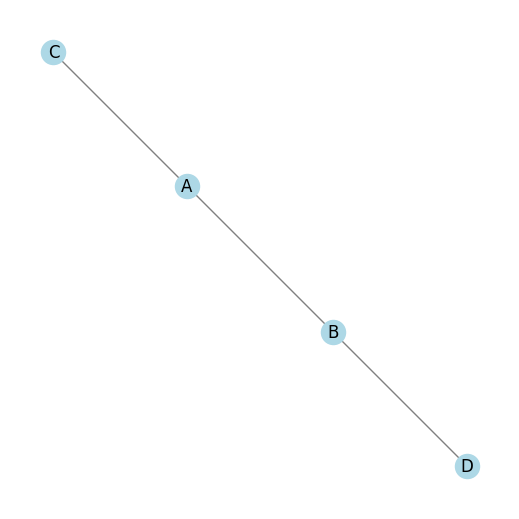

In [5]:
## 🔹 Create Graph

G = nx.Graph()
G.add_edges_from([("A","B"), ("A","C"), ("B","D")])
plt.figure(figsize=(5,5))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

In [6]:
## 🔹 Common Neighbors

list(nx.common_neighbors(G, "C", "D"))


[]

In [7]:
## 🔹 Jaccard Coefficient

preds = nx.jaccard_coefficient(G)
for u, v, p in preds:
    print(u, v, p)


D C 0.0
D A 0.5
B C 0.5


In [8]:
## 🔹 Adamic-Adar

preds = nx.adamic_adar_index(G)
for u, v, p in preds:
    print(u, v, p)


## 💡 Fraud Insight

# High score = potential hidden connection


D C 0
D A 1.4426950408889634
B C 1.4426950408889634


# 🧩 Summary

* Link prediction = predicting future/missing edges
* Heuristics → fast & interpretable
* ML → more powerful
* Critical for:

  * Fraud detection
  * Recommendations
  * Network analysis

---

### ❓ Interview Questions

* Difference between Jaccard and Adamic-Adar?
* Why is Adamic-Adar better for fraud detection?
* When would you use ML over heuristics?
* What are challenges in link prediction?

---

### 🧪 Mini Exercise Idea

* Compute:

  * Common neighbors
  * Jaccard score
* Predict top 3 likely links

